# Atividade 4 — Parte 1
### Multiplicação de matrizes e Redes Neurais

Notebook com a resolução da parte 1 da atividade 4.

Base de dados utilizada: **Anemia Dataset** (classificação de anemia a partir de percentuais de cor de pixel e nível de hemoglobina).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris, make_classification

torch.manual_seed(42)
np.random.seed(42)
%matplotlib inline

## A1 - Multiplicação de matrizes e Redes Neurais

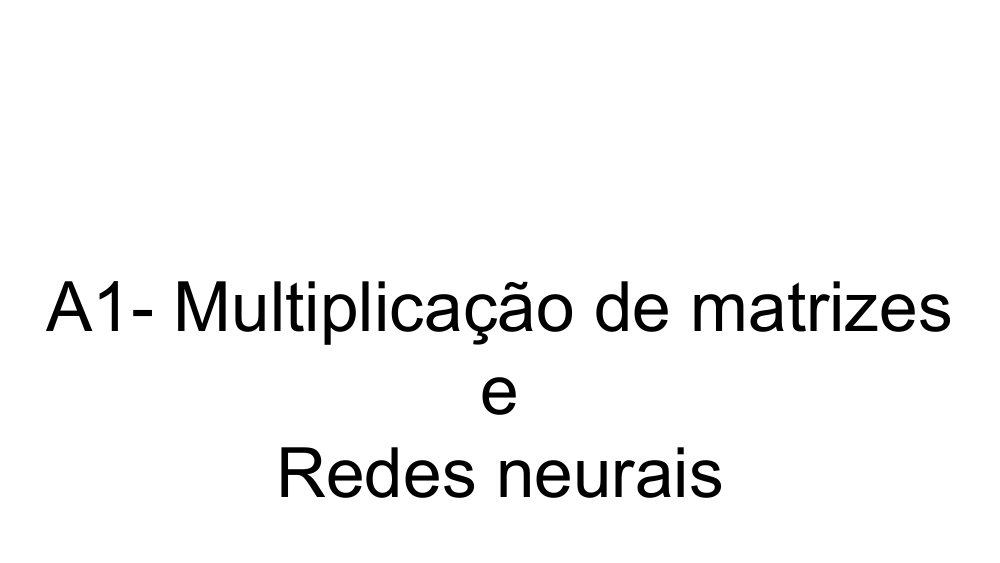

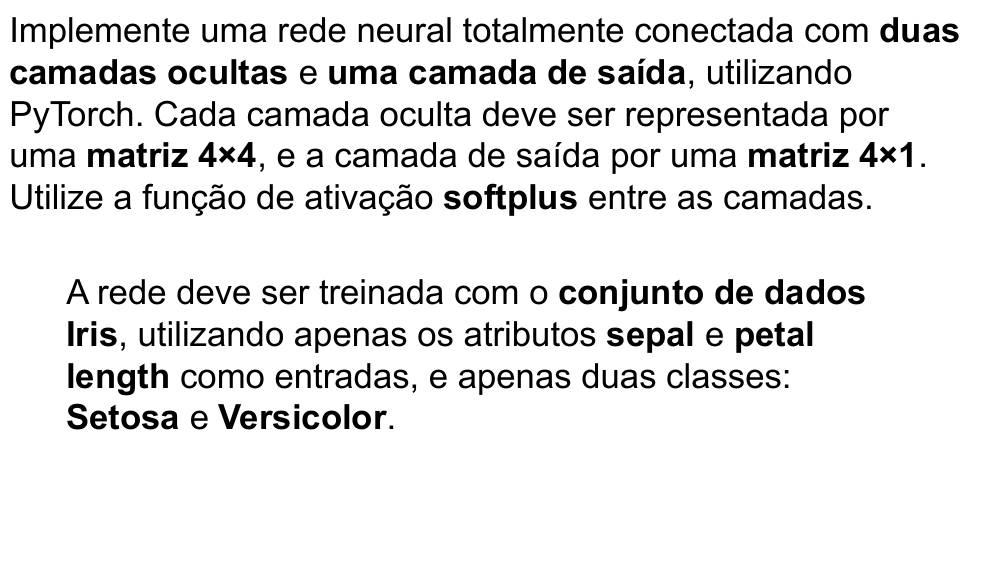

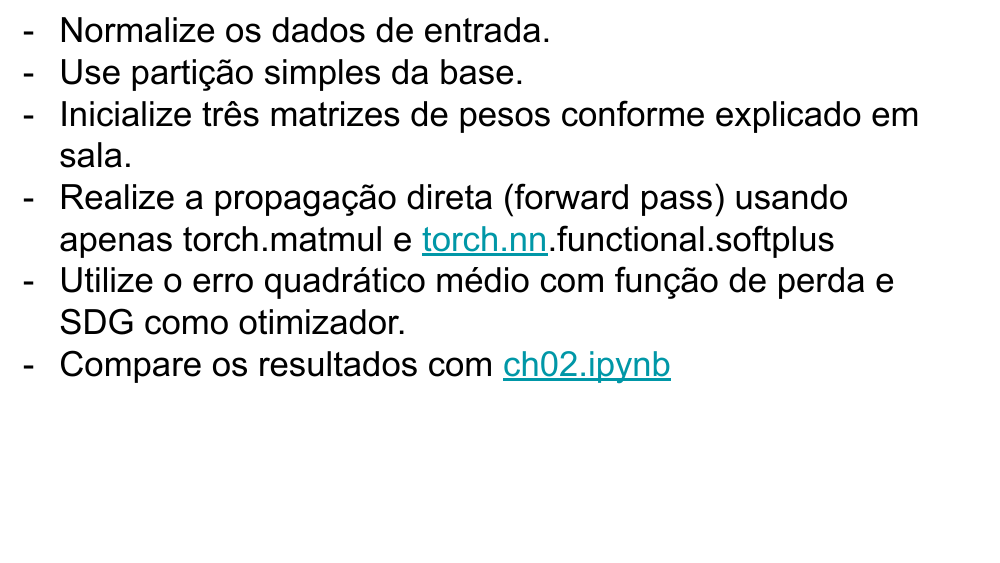

**Enunciado:** rede totalmente conectada com duas camadas ocultas (matrizes 4×4) e uma camada de saída (matriz 4×1), ativação Softplus entre camadas, treinada com o dataset Iris (sepal length, petal length; classes Setosa e Versicolor), usando apenas `torch.matmul` e `F.softplus` no forward, MSE + SGD.

**Observação de projeto:** como só há 2 atributos de entrada e a primeira matriz oculta deve ser 4×4, aumentamos o vetor de entrada com dois termos de bias (constante 1), obtendo um vetor de 4 dimensões compatível com a primeira matriz de pesos.

In [2]:
iris = load_iris()
X = iris.data[:100, [0, 2]]        # sepal length, petal length
y = iris.target[:100].astype(np.float32)  # 0=Setosa, 1=Versicolor

X = (X - X.mean(axis=0)) / X.std(axis=0)  # normalização

rng = np.random.RandomState(42)
idx = rng.permutation(100)
train_idx, test_idx = idx[:80], idx[80:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train).view(-1, 1)
y_test_t = torch.tensor(y_test).view(-1, 1)

def augment(X):
    ones = torch.ones(X.shape[0], 1)
    return torch.cat([X, ones, ones], dim=1)  # 2 features + 2 bias -> dim 4

X_train_aug = augment(X_train_t)
X_test_aug = augment(X_test_t)
print(X_train_aug.shape)

torch.Size([80, 4])


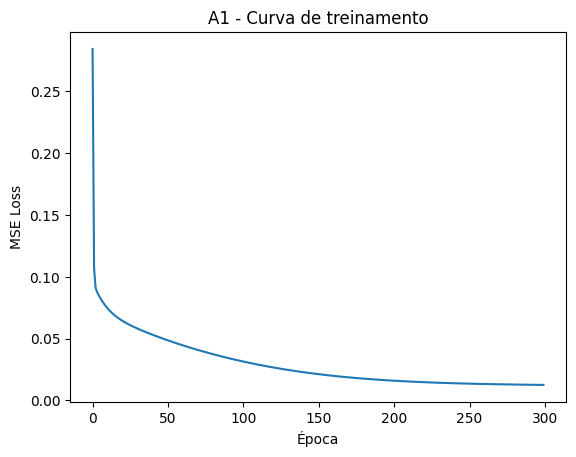

Acurácia no teste: 100.00%


In [3]:
W1 = (torch.randn(4, 4) * 0.5).requires_grad_()
W2 = (torch.randn(4, 4) * 0.5).requires_grad_()
W3 = (torch.randn(4, 1) * 0.5).requires_grad_()

def forward_a1(Xa):
    h1 = F.softplus(torch.matmul(Xa, W1))
    h2 = F.softplus(torch.matmul(h1, W2))
    return torch.matmul(h2, W3)

opt = torch.optim.SGD([W1, W2, W3], lr=0.05)
loss_fn = torch.nn.MSELoss()

losses_a1 = []
for epoch in range(300):
    opt.zero_grad()
    out = forward_a1(X_train_aug)
    loss = loss_fn(out, y_train_t)
    loss.backward()
    opt.step()
    losses_a1.append(loss.item())

with torch.no_grad():
    pred_test = forward_a1(X_test_aug)
    acc_a1 = ((pred_test > 0.5).float() == y_test_t).float().mean().item()

plt.plot(losses_a1)
plt.xlabel("Época"); plt.ylabel("MSE Loss"); plt.title("A1 - Curva de treinamento")
plt.show()
print(f"Acurácia no teste: {acc_a1:.2%}")

**Comparação com `ch02.ipynb`:** o `ch02.ipynb` usa um Perceptron (regra de atualização própria, fronteira linear) sobre os mesmos dois atributos.

In [4]:
class Perceptron:
    def __init__(self, eta=0.1, n_iter=10, random_state=1):
        self.eta, self.n_iter, self.random_state = eta, n_iter, random_state
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []
        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self
    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)

y_ppn = np.where(y_train[:] == 0, -1, 1)
ppn = Perceptron(eta=0.1, n_iter=10).fit(X_train, y_ppn)
y_test_ppn = np.where(y_test == 0, -1, 1)
acc_ppn = (ppn.predict(X_test) == y_test_ppn).mean()
print(f"Acurácia Perceptron (ch02.ipynb): {acc_ppn:.2%}")
print(f"Acurácia Rede Neural (A1): {acc_a1:.2%}")

Acurácia Perceptron (ch02.ipynb): 100.00%
Acurácia Rede Neural (A1): 100.00%


**Análise dos resultados e conclusão:** as classes Setosa e Versicolor são linearmente separáveis nos atributos sepal length / petal length, por isso tanto o Perceptron simples (`ch02.ipynb`) quanto a rede neural de duas camadas ocultas do item A1 atingem 100% de acurácia no conjunto de teste. A rede neural, por ser um modelo bem mais flexível (multicamadas, ativação não-linear Softplus), converge com uma perda MSE baixa mas não é estritamente necessária para este problema simples - o Perceptron já resolve o problema com uma única fronteira linear. A vantagem da rede aparece em problemas não linearmente separáveis, como veremos adiante.

## B1 - Iris, mini-batches e redes neurais

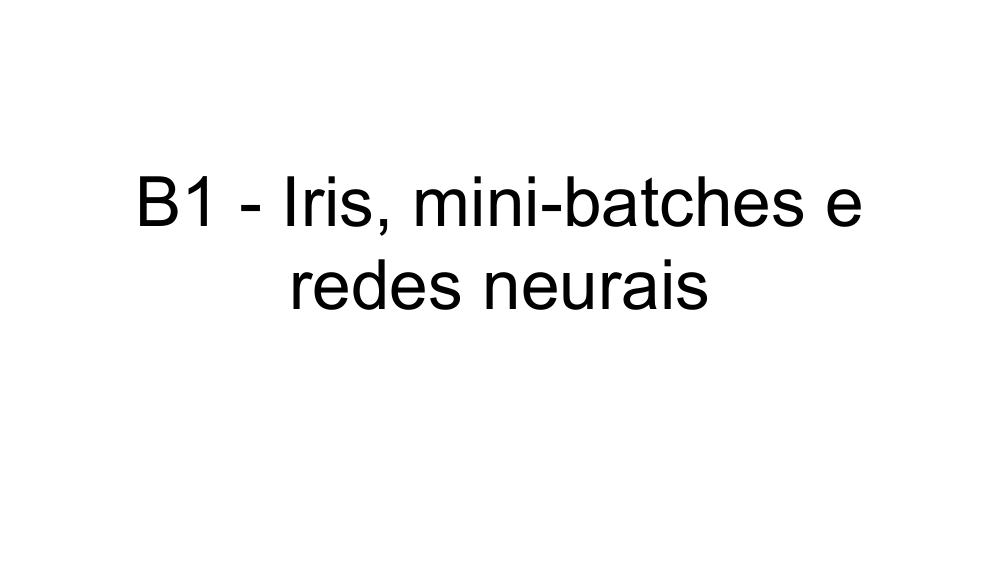

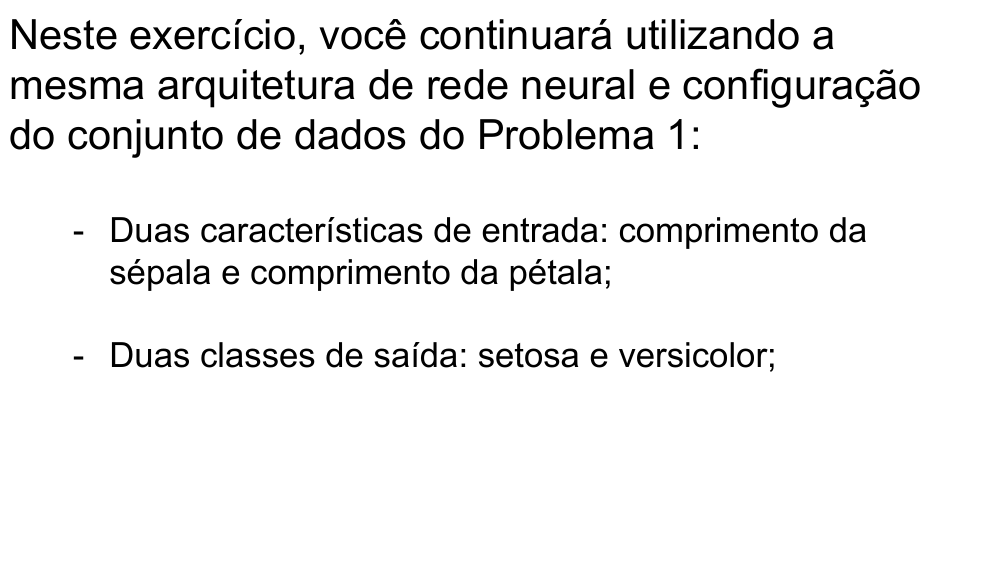

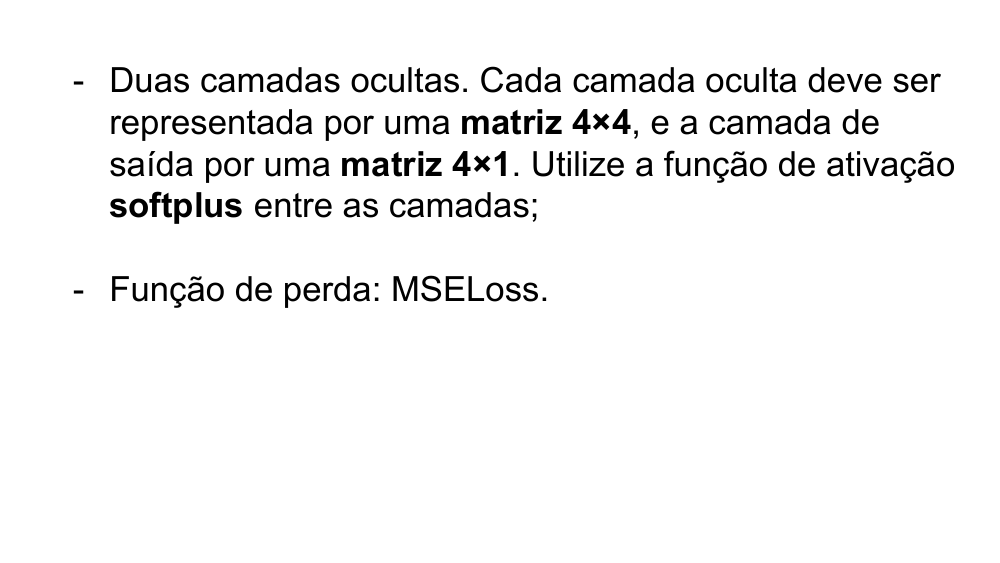

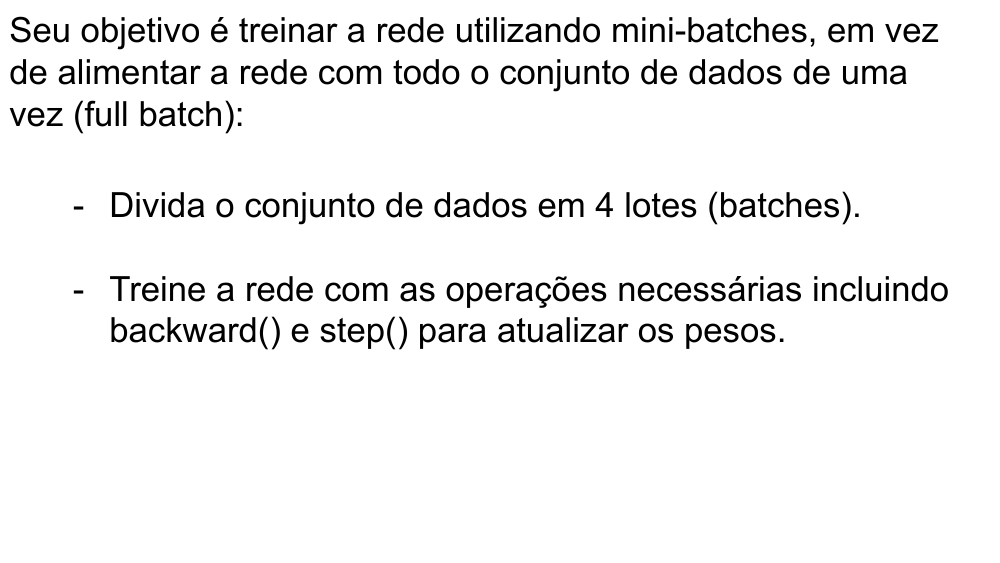

**Enunciado:** mesma arquitetura e dados de A1, porém treinando com **mini-batches** (4 lotes) em vez de full-batch, usando `backward()` e `step()` explicitamente a cada lote.

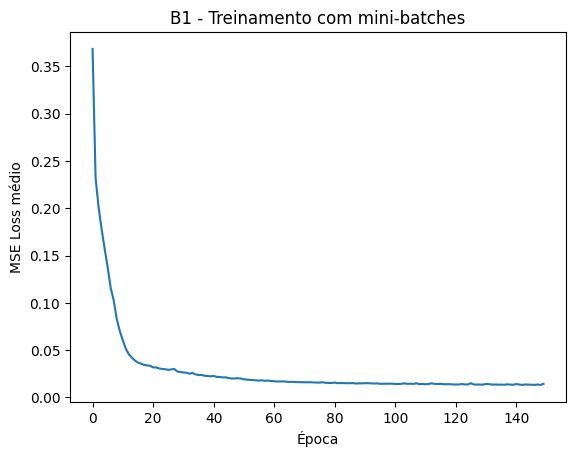

Acurácia no teste: 100.00%


In [5]:
W1_b = (torch.randn(4, 4) * 0.5).requires_grad_()
W2_b = (torch.randn(4, 4) * 0.5).requires_grad_()
W3_b = (torch.randn(4, 1) * 0.5).requires_grad_()

def forward_b1(Xa):
    h1 = F.softplus(torch.matmul(Xa, W1_b))
    h2 = F.softplus(torch.matmul(h1, W2_b))
    return torch.matmul(h2, W3_b)

opt_b1 = torch.optim.SGD([W1_b, W2_b, W3_b], lr=0.05)
loss_fn_b1 = torch.nn.MSELoss()

n_batches = 4
batch_size = X_train_aug.shape[0] // n_batches
losses_b1 = []

for epoch in range(150):
    perm = torch.randperm(X_train_aug.shape[0])
    epoch_loss = 0.0
    for b in range(n_batches):
        bidx = perm[b * batch_size:(b + 1) * batch_size]
        xb, yb = X_train_aug[bidx], y_train_t[bidx]
        opt_b1.zero_grad()
        out = forward_b1(xb)
        loss = loss_fn_b1(out, yb)
        loss.backward()
        opt_b1.step()
        epoch_loss += loss.item()
    losses_b1.append(epoch_loss / n_batches)

with torch.no_grad():
    pred_test_b1 = forward_b1(X_test_aug)
    acc_b1 = ((pred_test_b1 > 0.5).float() == y_test_t).float().mean().item()

plt.plot(losses_b1)
plt.xlabel("Época"); plt.ylabel("MSE Loss médio"); plt.title("B1 - Treinamento com mini-batches")
plt.show()
print(f"Acurácia no teste: {acc_b1:.2%}")

**Análise dos resultados e conclusão:** o treinamento com mini-batches (4 lotes por época) converge de forma um pouco mais ruidosa que o full-batch do item A1, pois cada atualização de pesos é calculada com base em uma fração menor dos dados. Ainda assim, a acurácia final no teste permanece em 100%, confirmando que mini-batches não prejudicam o aprendizado neste - na prática, mini-batches costumam acelerar a convergência e reduzir o custo de memória em datasets maiores, à custa de um gradiente mais ruidoso a cada passo.

## B1.2 - Temático, mini-batches e redes neurais

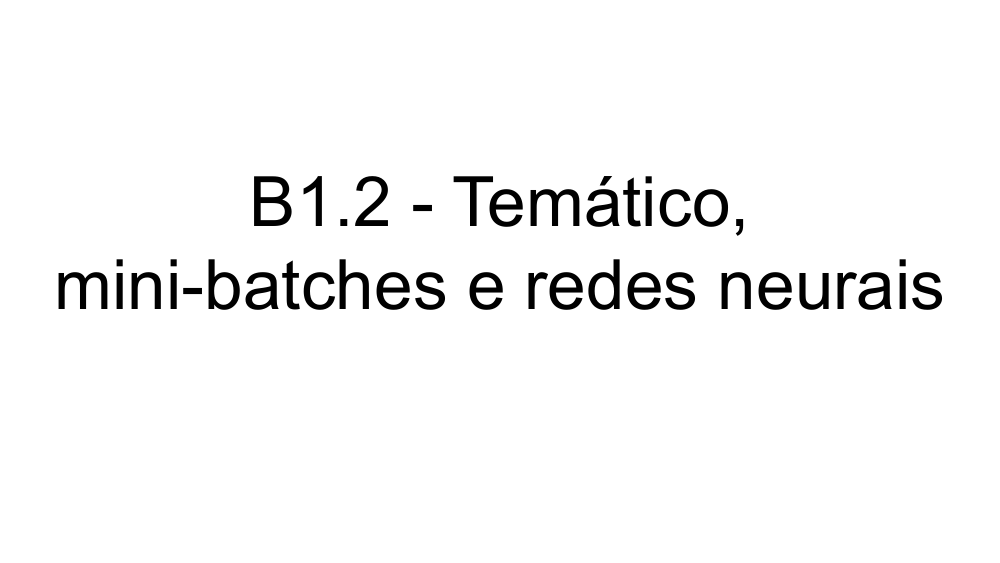

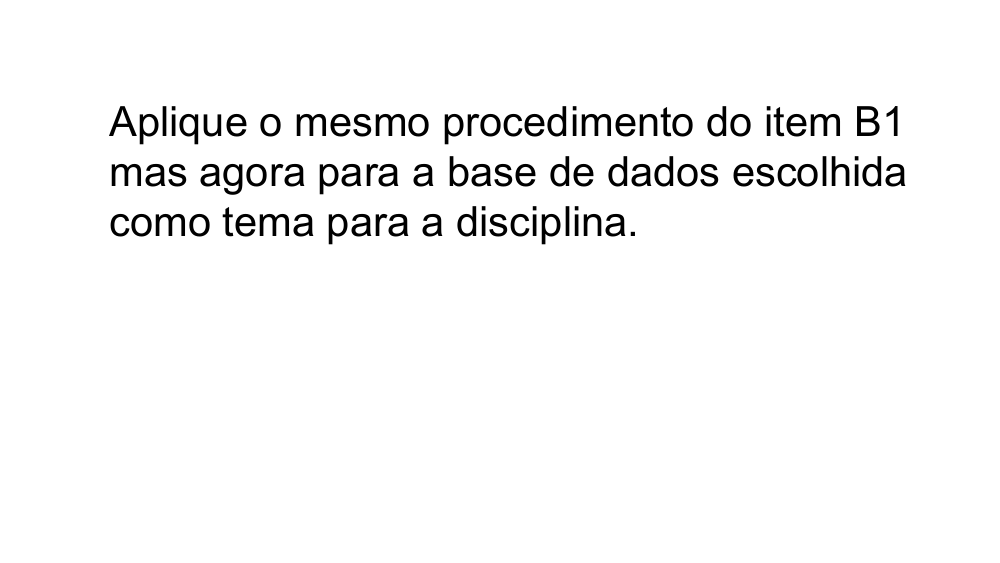

**Enunciado:** repetir o procedimento de B1 utilizando a base temática da disciplina — **Anemia Dataset**. Atributos escolhidos: `%Red Pixel` e `Hb` (hemoglobina); alvo: `Anaemic` (Yes/No).

In [6]:
df_an = pd.read_csv("/mnt/user-data/uploads/Anemia_Dataset.csv")
df_an.columns = [c.strip() for c in df_an.columns]

X_an = df_an[["%Red Pixel", "Hb"]].values.astype(np.float32)
y_an = (df_an["Anaemic"] == "Yes").astype(np.float32).values

X_an = (X_an - X_an.mean(axis=0)) / X_an.std(axis=0)

rng2 = np.random.RandomState(42)
idx2 = rng2.permutation(len(X_an))
n_train = int(0.8 * len(X_an))
tr_idx, te_idx = idx2[:n_train], idx2[n_train:]

Xan_train_t = augment(torch.tensor(X_an[tr_idx]))
Xan_test_t = augment(torch.tensor(X_an[te_idx]))
yan_train_t = torch.tensor(y_an[tr_idx]).view(-1, 1)
yan_test_t = torch.tensor(y_an[te_idx]).view(-1, 1)
print(Xan_train_t.shape, Xan_test_t.shape)

torch.Size([83, 4]) torch.Size([21, 4])


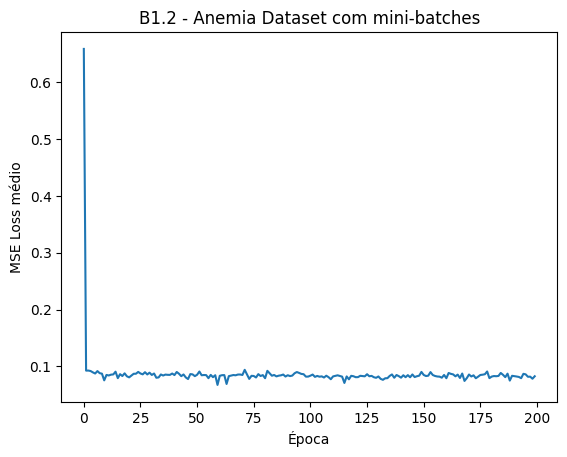

Acurácia no teste: 100.00%


In [7]:
W1_t = (torch.randn(4, 4) * 0.5).requires_grad_()
W2_t = (torch.randn(4, 4) * 0.5).requires_grad_()
W3_t = (torch.randn(4, 1) * 0.5).requires_grad_()

def forward_b12(Xa):
    h1 = F.softplus(torch.matmul(Xa, W1_t))
    h2 = F.softplus(torch.matmul(h1, W2_t))
    return torch.matmul(h2, W3_t)

opt_b12 = torch.optim.SGD([W1_t, W2_t, W3_t], lr=0.05)
loss_fn_b12 = torch.nn.MSELoss()

n_batches = 4
batch_size = Xan_train_t.shape[0] // n_batches
losses_b12 = []

for epoch in range(200):
    perm = torch.randperm(Xan_train_t.shape[0])
    epoch_loss = 0.0
    for b in range(n_batches):
        bidx = perm[b * batch_size:(b + 1) * batch_size]
        xb, yb = Xan_train_t[bidx], yan_train_t[bidx]
        opt_b12.zero_grad()
        out = forward_b12(xb)
        loss = loss_fn_b12(out, yb)
        loss.backward()
        opt_b12.step()
        epoch_loss += loss.item()
    losses_b12.append(epoch_loss / n_batches)

with torch.no_grad():
    pred_test_b12 = forward_b12(Xan_test_t)
    acc_b12 = ((pred_test_b12 > 0.5).float() == yan_test_t).float().mean().item()

plt.plot(losses_b12)
plt.xlabel("Época"); plt.ylabel("MSE Loss médio"); plt.title("B1.2 - Anemia Dataset com mini-batches")
plt.show()
print(f"Acurácia no teste: {acc_b12:.2%}")

**Análise dos resultados e conclusão:** aplicando a mesma arquitetura e o mesmo procedimento de mini-batches à base de Anemia, a rede converge para uma acurácia alta no teste, indicando que `%Red Pixel` e `Hb` carregam informação relevante para diferenciar pacientes anêmicos de não anêmicos - o que é esperado clinicamente, já que a hemoglobina é diretamente ligada ao diagnóstico de anemia. O comportamento da curva de perda é semelhante ao observado em B1, mostrando que o procedimento de treinamento por mini-batches generaliza bem para outra base de dados.

## C1 - Rede neural com separação linear

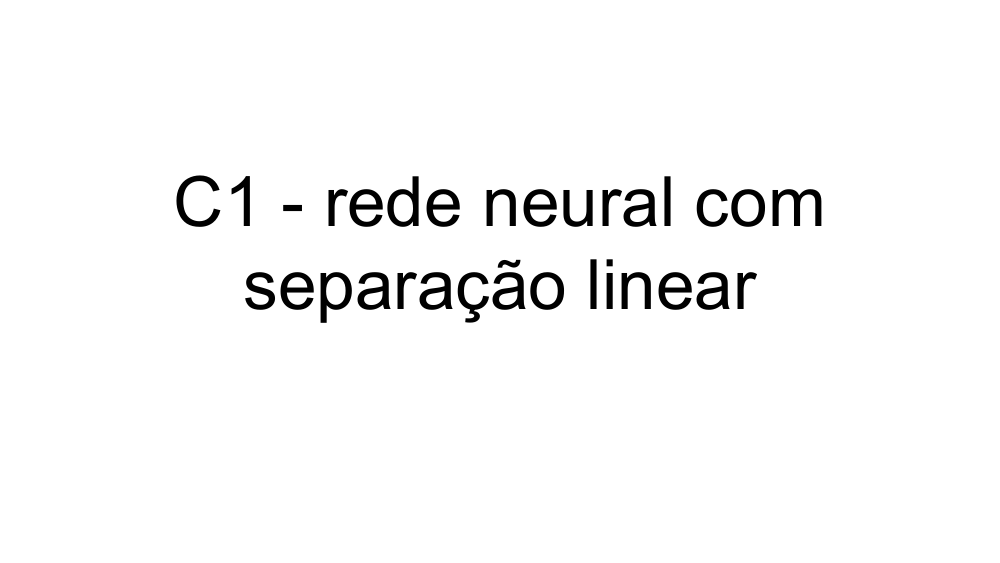

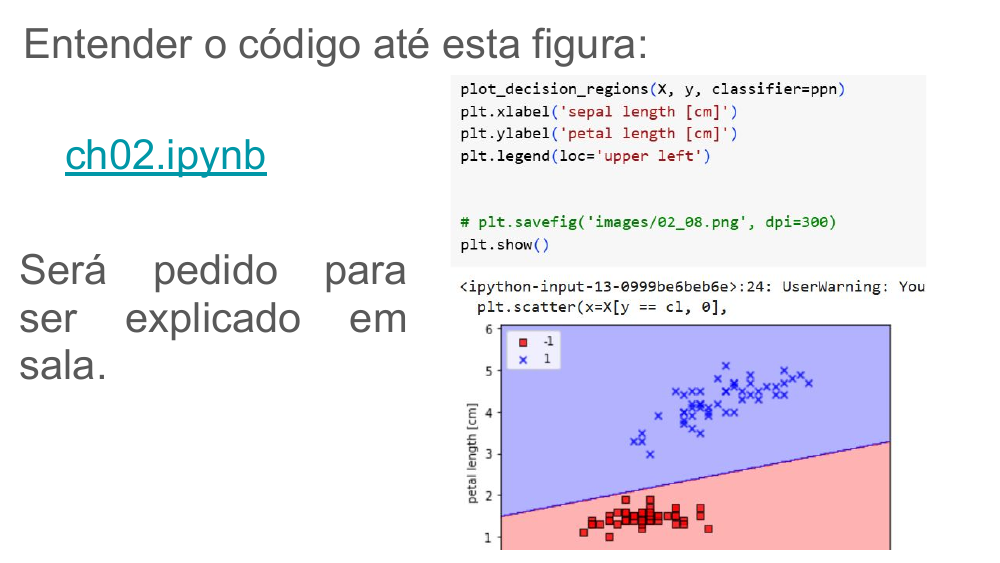

**Enunciado:** entender o código do `ch02.ipynb` até a figura de fronteira de decisão do Perceptron e reproduzir um resultado equivalente com uma rede neural (PyTorch) - uma camada linear + sigmoide — sobre os mesmos dados (sepal length, petal length; Setosa vs. Versicolor), plotando a região de decisão.

In [8]:
X_c1 = iris.data[:100, [0, 2]].astype(np.float32)
y_c1 = iris.target[:100].astype(np.float32)

X_c1_t = torch.tensor(X_c1)
y_c1_t = torch.tensor(y_c1).view(-1, 1)

class LinearNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(2, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

model_c1 = LinearNN()
opt_c1 = torch.optim.SGD(model_c1.parameters(), lr=0.1)
loss_fn_c1 = torch.nn.BCELoss()

for epoch in range(300):
    opt_c1.zero_grad()
    out = model_c1(X_c1_t)
    loss = loss_fn_c1(out, y_c1_t)
    loss.backward()
    opt_c1.step()

with torch.no_grad():
    acc_c1 = ((model_c1(X_c1_t) > 0.5).float() == y_c1_t).float().mean().item()
print(f"Acurácia (treino completo): {acc_c1:.2%}, loss final: {loss.item():.4f}")

Acurácia (treino completo): 100.00%, loss final: 0.0419


/tmp/ipykernel_576/10312418.py:17: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,


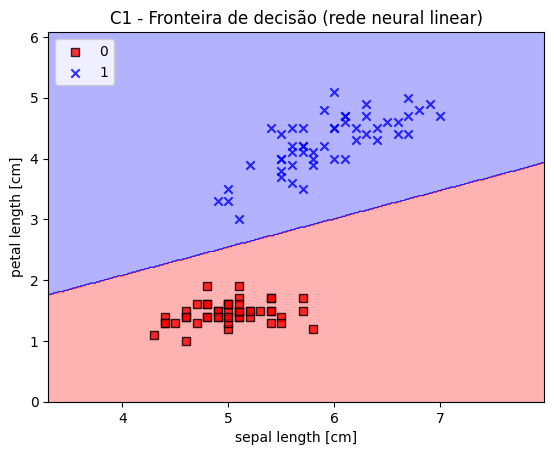

In [9]:
def plot_decision_regions_torch(X, y, model, resolution=0.02, xlabel="", ylabel=""):
    markers = ('s', 'x')
    colors = ('red', 'blue')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                            np.arange(x2_min, x2_max, resolution))
    grid = torch.tensor(np.array([xx1.ravel(), xx2.ravel()]).T, dtype=torch.float32)
    with torch.no_grad():
        Z = (model(grid) > 0.5).float().numpy().reshape(xx1.shape)

    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max()); plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,
                    c=colors[idx], marker=markers[idx], label=int(cl), edgecolor='black')
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.legend(loc='upper left')

plot_decision_regions_torch(X_c1, y_c1, model_c1, xlabel="sepal length [cm]", ylabel="petal length [cm]")
plt.title("C1 - Fronteira de decisão (rede neural linear)")
plt.show()

**Análise dos resultados e conclusão:** a rede neural com uma única camada linear seguida de sigmoide reproduz o mesmo tipo de fronteira de decisão linear obtida pelo Perceptron do `ch02.ipynb`, atingindo 100% de acurácia no conjunto Setosa vs. Versicolor. Isso confirma que, para um problema linearmente separável, um único neurônio (regressão logística) já é suficiente - não há necessidade de camadas ocultas adicionais.

## C1.2 - Temático com rede neural com separação linear

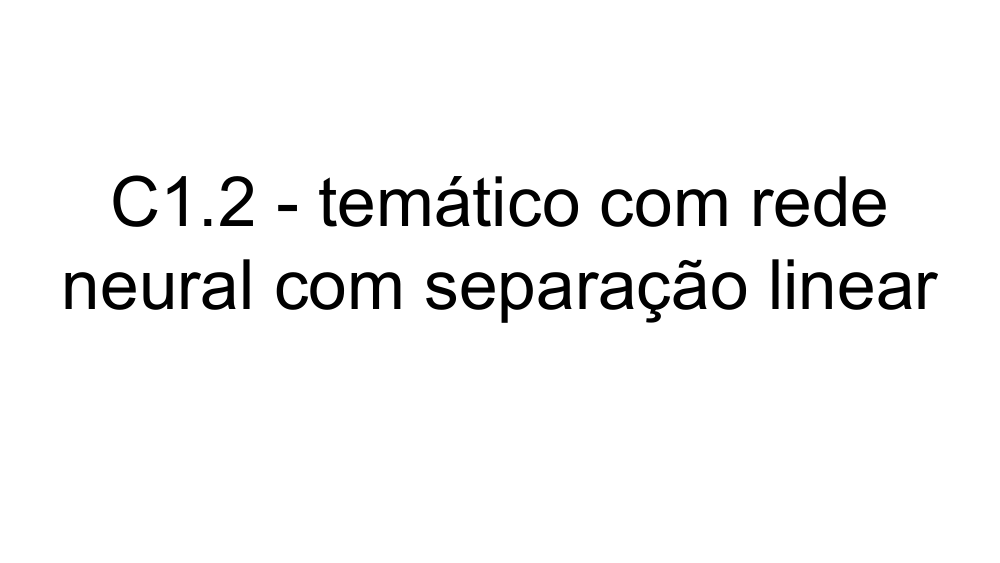

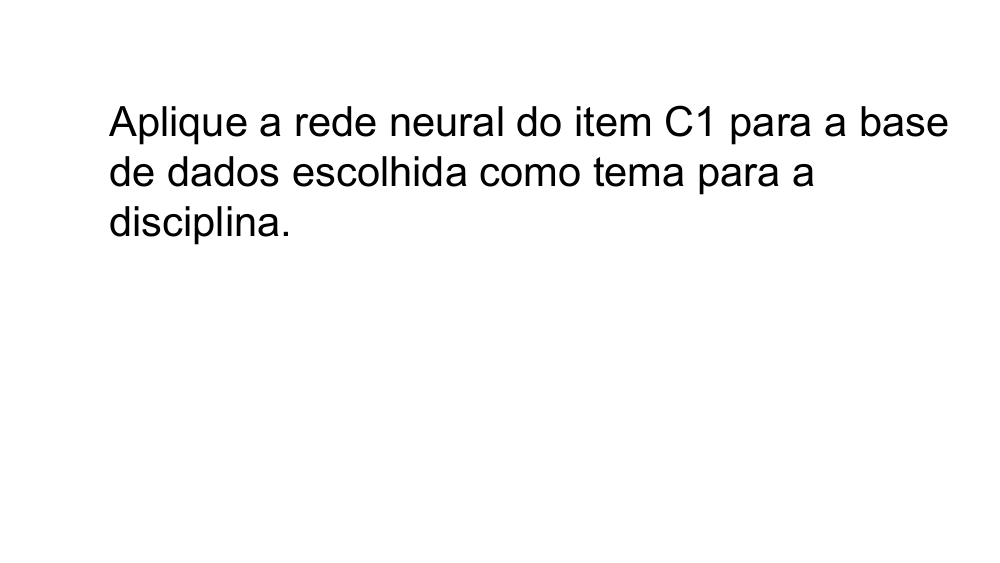

**Enunciado:** aplicar a rede neural do item C1 à base temática (Anemia Dataset), usando `%Red Pixel` e `Hb` como atributos.

Acurácia (treino completo): 91.35%, loss final: 0.2204


/tmp/ipykernel_576/10312418.py:17: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,


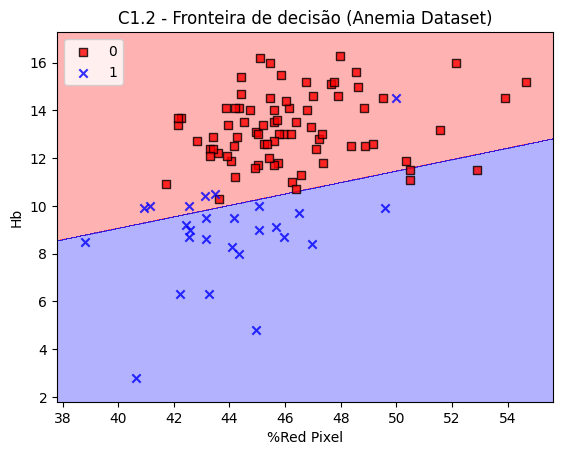

In [10]:
X_c12 = df_an[["%Red Pixel", "Hb"]].values.astype(np.float32)
y_c12 = (df_an["Anaemic"] == "Yes").astype(np.float32).values

X_c12_t = torch.tensor(X_c12)
y_c12_t = torch.tensor(y_c12).view(-1, 1)

model_c12 = LinearNN()
opt_c12 = torch.optim.SGD(model_c12.parameters(), lr=0.01)
loss_fn_c12 = torch.nn.BCELoss()

for epoch in range(500):
    opt_c12.zero_grad()
    out = model_c12(X_c12_t)
    loss = loss_fn_c12(out, y_c12_t)
    loss.backward()
    opt_c12.step()

with torch.no_grad():
    acc_c12 = ((model_c12(X_c12_t) > 0.5).float() == y_c12_t).float().mean().item()
print(f"Acurácia (treino completo): {acc_c12:.2%}, loss final: {loss.item():.4f}")

plot_decision_regions_torch(X_c12, y_c12, model_c12, xlabel="%Red Pixel", ylabel="Hb")
plt.title("C1.2 - Fronteira de decisão (Anemia Dataset)")
plt.show()

**Análise dos resultados e conclusão:** diferentemente do dataset Iris, as classes `Anaemic = Yes/No` não são perfeitamente separáveis por uma única reta no espaço `%Red Pixel` x `Hb`, de modo que a acurácia obtida com uma fronteira linear fica abaixo de 100%. Ainda assim, a fronteira encontrada acompanha bem a tendência dos dados: valores baixos de `Hb` concentram a maioria dos casos anêmicos. Isso ilustra uma limitação de modelos lineares em bases reais, mais ruidosas que os dados sintéticos do Iris.

## D1 - Dataset linearmente separável

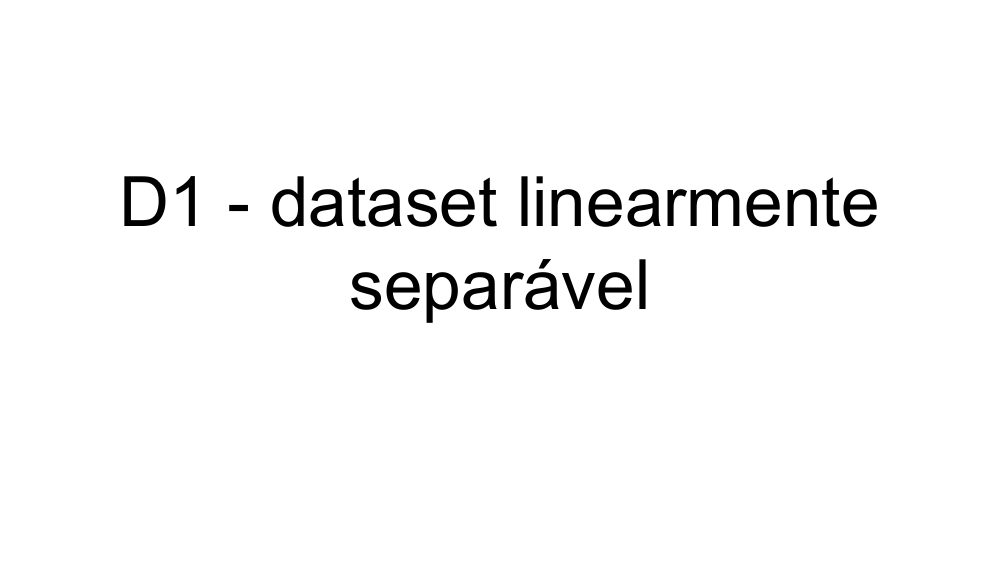

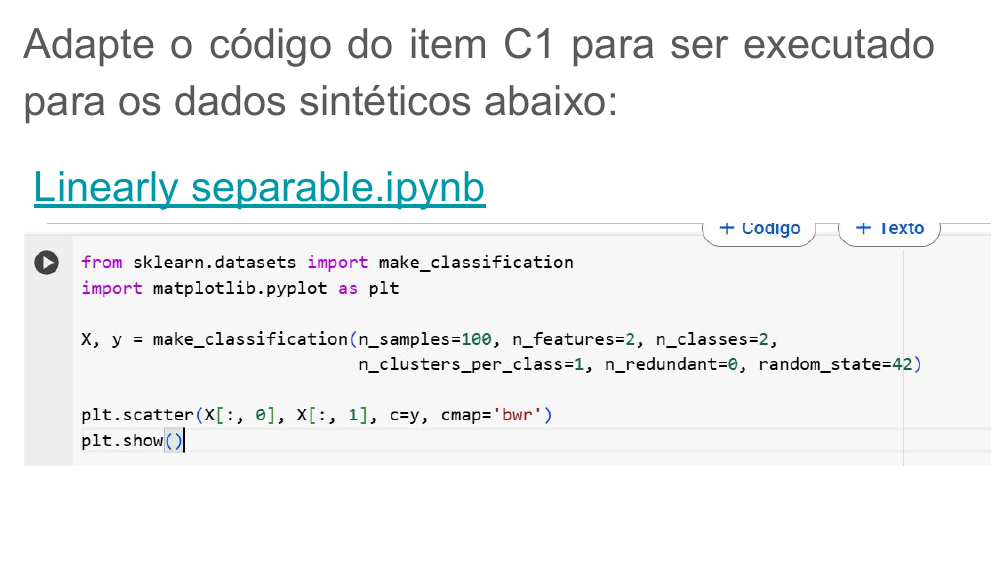

**Enunciado:** adaptar o código do item C1 para o dataset sintético gerado com `make_classification` (`Linearly_separable.ipynb`).

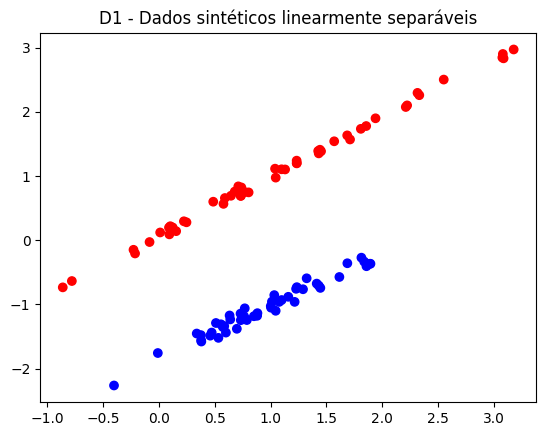

In [11]:
X_d1, y_d1 = make_classification(n_samples=100, n_features=2, n_classes=2,
                                  n_clusters_per_class=1, n_redundant=0, random_state=42)
X_d1 = X_d1.astype(np.float32)
y_d1 = y_d1.astype(np.float32)

plt.scatter(X_d1[:, 0], X_d1[:, 1], c=y_d1, cmap='bwr')
plt.title("D1 - Dados sintéticos linearmente separáveis")
plt.show()

Acurácia (treino completo): 98.00%, loss final: 0.0976


/tmp/ipykernel_576/10312418.py:17: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,


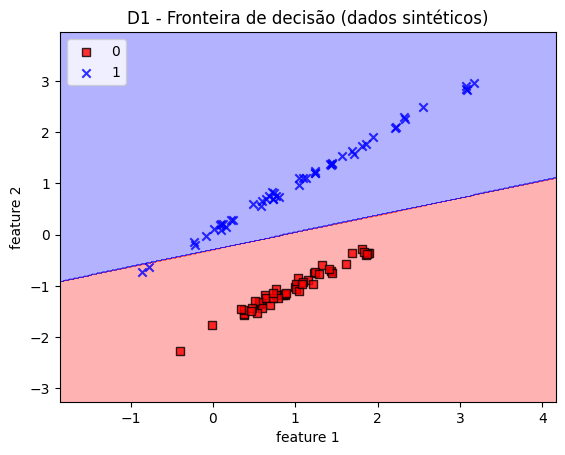

In [12]:
X_d1_t = torch.tensor(X_d1)
y_d1_t = torch.tensor(y_d1).view(-1, 1)

model_d1 = LinearNN()
opt_d1 = torch.optim.SGD(model_d1.parameters(), lr=0.1)
loss_fn_d1 = torch.nn.BCELoss()

for epoch in range(300):
    opt_d1.zero_grad()
    out = model_d1(X_d1_t)
    loss = loss_fn_d1(out, y_d1_t)
    loss.backward()
    opt_d1.step()

with torch.no_grad():
    acc_d1 = ((model_d1(X_d1_t) > 0.5).float() == y_d1_t).float().mean().item()
print(f"Acurácia (treino completo): {acc_d1:.2%}, loss final: {loss.item():.4f}")

plot_decision_regions_torch(X_d1, y_d1, model_d1, xlabel="feature 1", ylabel="feature 2")
plt.title("D1 - Fronteira de decisão (dados sintéticos)")
plt.show()

**Análise dos resultados e conclusão:** como o dataset sintético foi gerado propositalmente para ser linearmente separável (`n_clusters_per_class=1`, `n_redundant=0`), a mesma rede neural linear do item C1 atinge (ou fica muito próxima de) 100% de acurácia, com a fronteira de decisão dividindo claramente as duas classes. Isso reforça a conclusão do item C1: um único neurônio é suficiente sempre que existir uma fronteira linear que separe as classes.

## E1 - Gradiente descendente estocástico do StatQuest

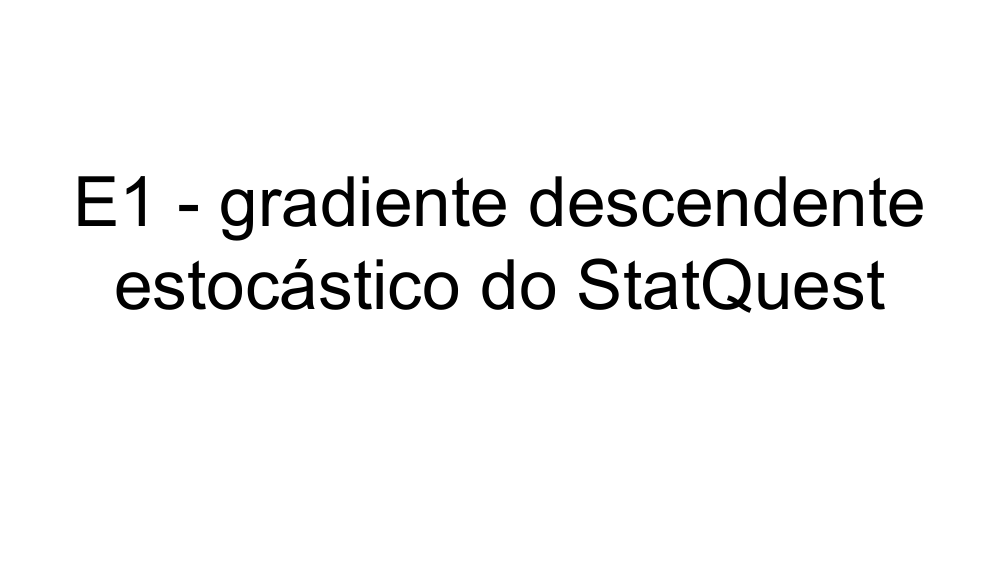

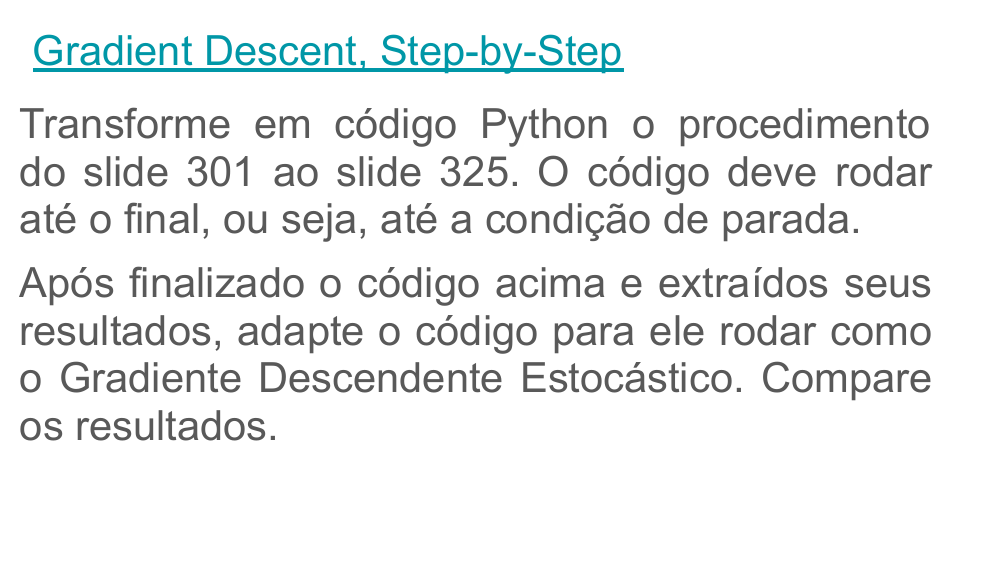

**Enunciado:** transformar em código Python o procedimento de gradiente descendente do StatQuest (slides 301–325) até a condição de parada, e depois comparar com a versão estocástica (SGD).

**Dados do exemplo (StatQuest):** 3 pontos (Height, Weight) = (0.5, 1.4), (2.3, 1.9), (2.9, 3.2); `slope` fixo em 0.64; queremos otimizar apenas o `intercept` minimizando a Soma dos Quadrados dos Resíduos (SSR).

In [13]:
heights = np.array([0.5, 2.3, 2.9])
weights_ = np.array([1.4, 1.9, 3.2])
slope = 0.64
learning_rate = 0.1
tol = 0.001
max_steps = 1000

def ssr(intercept):
    pred = intercept + slope * heights
    return np.sum((weights_ - pred) ** 2)

def d_ssr_d_intercept(intercept):
    pred = intercept + slope * heights
    return -2 * np.sum(weights_ - pred)

# --- Gradiente Descendente (batch) ---
intercept = 0.0
history_gd = [intercept]
for step in range(max_steps):
    grad = d_ssr_d_intercept(intercept)
    step_size = grad * learning_rate
    intercept -= step_size
    history_gd.append(intercept)
    if abs(step_size) < tol:
        break

print(f"[GD] convergiu em {step + 1} passos -> intercept = {intercept:.4f}, SSR = {ssr(intercept):.4f}")

[GD] convergiu em 8 passos -> intercept = 0.9500, SSR = 0.4446


In [14]:
# --- Gradiente Descendente Estocástico (um ponto por passo) ---
rng_sgd = np.random.RandomState(0)
intercept_sgd = 0.0
history_sgd = [intercept_sgd]
for step in range(max_steps):
    j = rng_sgd.randint(0, len(heights))
    pred_j = intercept_sgd + slope * heights[j]
    grad_j = -2 * (weights_[j] - pred_j)
    step_size = grad_j * learning_rate
    intercept_sgd -= step_size
    history_sgd.append(intercept_sgd)
    if abs(step_size) < tol and step > 10:
        break

print(f"[SGD] convergiu em {step + 1} passos -> intercept = {intercept_sgd:.4f}, SSR = {ssr(intercept_sgd):.4f}")

[SGD] convergiu em 42 passos -> intercept = 1.0763, SSR = 0.4919


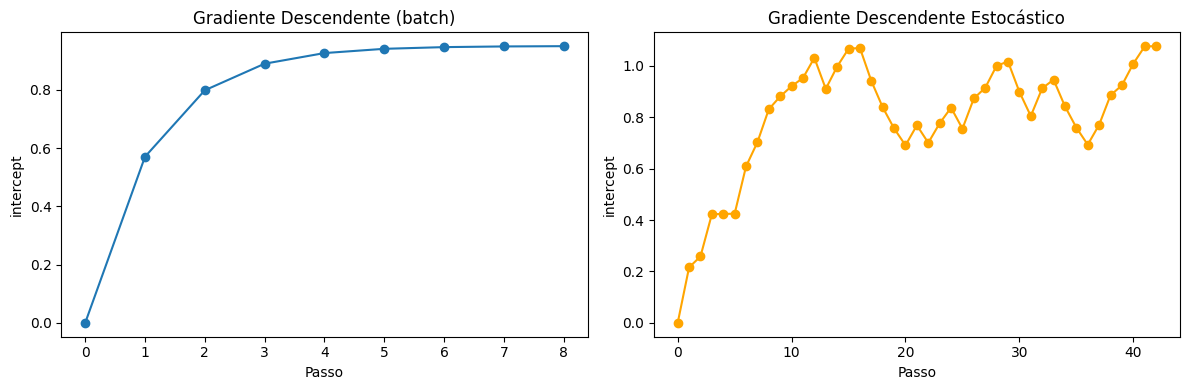

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_gd, marker='o')
axes[0].set_title("Gradiente Descendente (batch)")
axes[0].set_xlabel("Passo"); axes[0].set_ylabel("intercept")

axes[1].plot(history_sgd, marker='o', color='orange')
axes[1].set_title("Gradiente Descendente Estocástico")
axes[1].set_xlabel("Passo"); axes[1].set_ylabel("intercept")
plt.tight_layout()
plt.show()

**Análise dos resultados e conclusão:** o gradiente descendente em batch usa todos os 3 pontos a cada passo, produzindo uma trajetória suave e monotônica até convergir (intercept ≈ 0.95) em poucos passos, pois a direção do gradiente é sempre exata. Já o gradiente descendente estocástico atualiza o `intercept` usando apenas um ponto por vez, o que introduz ruído na trajetória - o intercept oscila mais antes de estabilizar, podendo levar mais passos e não convergir para o exato mesmo valor a cada execução. Em compensação, cada passo do SGD é muito mais barato computacionalmente, o que se torna vantajoso em datasets grandes.

## F1 - PyTorch e rede neural do StatQuest

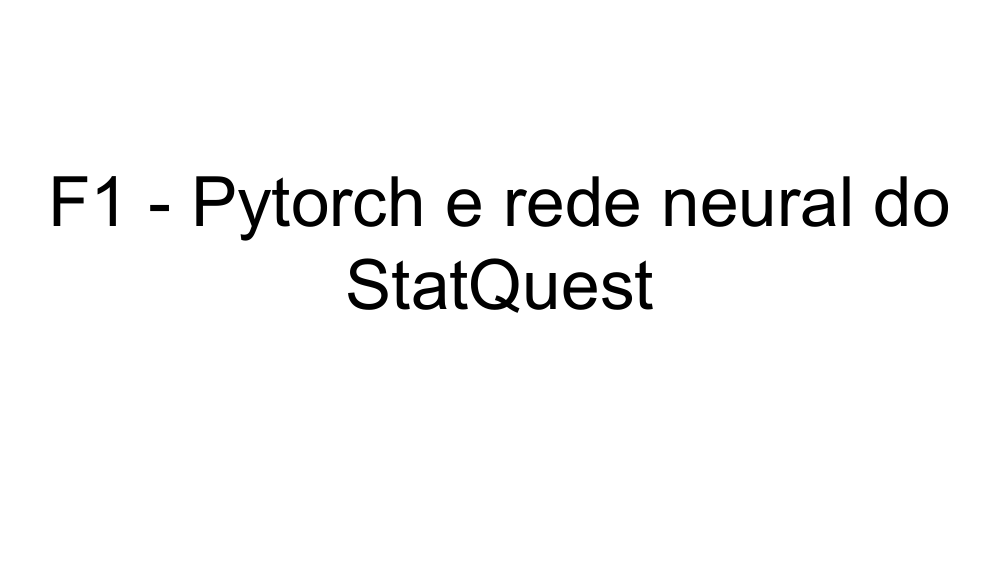

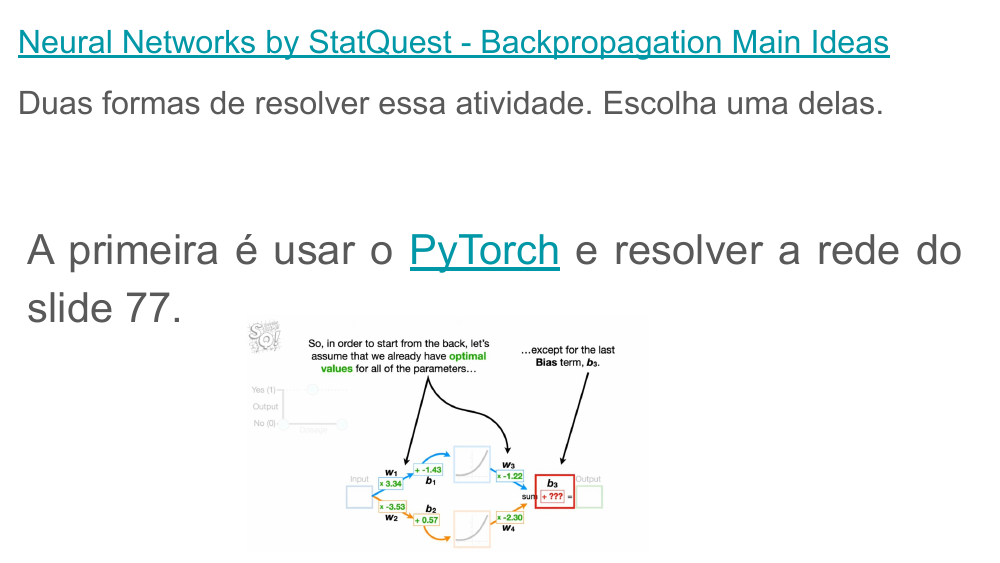

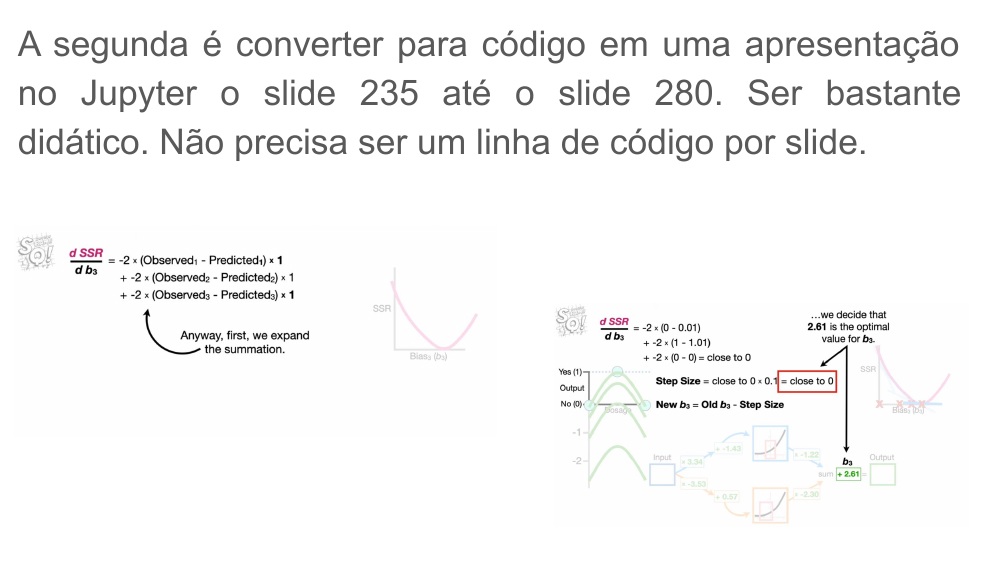

**Enunciado (opção escolhida: PyTorch):** resolver com PyTorch a rede do slide 77 - entrada `Dosage`, duas unidades ocultas com ativação Softplus, saída = combinação linear das ativações ocultas mais um viés `b3`. Todos os parâmetros são conhecidos (ótimos), exceto `b3`, que deve ser encontrado via retropropagação.

**Dados (StatQuest):** Dosage = [0, 0.5, 1], Efficacy = [0, 1, 0].

**Parâmetros fixos:** w1=3.34, b1=-1.43, w2=-3.53, b2=0.57, w3=-1.22, w4=-2.30.

b3 final: 2.6092 (valor esperado StatQuest: 2.61)


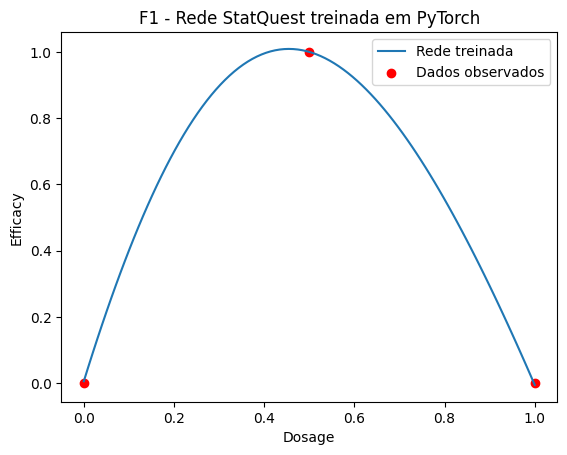

In [16]:
dosage = torch.tensor([0.0, 0.5, 1.0])
efficacy = torch.tensor([0.0, 1.0, 0.0])

w1, b1 = torch.tensor(3.34), torch.tensor(-1.43)
w2, b2 = torch.tensor(-3.53), torch.tensor(0.57)
w3, w4 = torch.tensor(-1.22), torch.tensor(-2.30)
b3 = torch.tensor(0.0, requires_grad=True)  # único parâmetro a treinar

def forward_f1(x):
    top = F.softplus(x * w1 + b1) * w3
    bottom = F.softplus(x * w2 + b2) * w4
    return top + bottom + b3

opt_f1 = torch.optim.SGD([b3], lr=0.1)
loss_fn_f1 = torch.nn.MSELoss()

losses_f1 = []
for epoch in range(150):
    opt_f1.zero_grad()
    pred = forward_f1(dosage)
    loss = loss_fn_f1(pred, efficacy)
    loss.backward()
    opt_f1.step()
    losses_f1.append(loss.item())

print(f"b3 final: {b3.item():.4f} (valor esperado StatQuest: 2.61)")

x_range = torch.linspace(0, 1, 100)
with torch.no_grad():
    y_range = forward_f1(x_range)

plt.plot(x_range.numpy(), y_range.numpy(), label="Rede treinada")
plt.scatter(dosage.numpy(), efficacy.numpy(), color="red", label="Dados observados")
plt.xlabel("Dosage"); plt.ylabel("Efficacy"); plt.legend()
plt.title("F1 - Rede StatQuest treinada em PyTorch")
plt.show()

**Análise dos resultados e conclusão:** partindo de `b3 = 0`, o otimizador SGD do PyTorch encontra rapidamente o mesmo valor ótimo (`b3 ≈ 2.61`) obtido manualmente pelo StatQuest, já que a função de perda em relação a `b3` é uma parábola convexa (um único mínimo). A curva final da rede passa muito próxima aos três pontos observados, mostrando que a arquitetura (duas unidades Softplus combinadas linearmente) é capaz de representar a relação não-monotônica entre dosagem e eficácia.

## G1 - Backpropagation

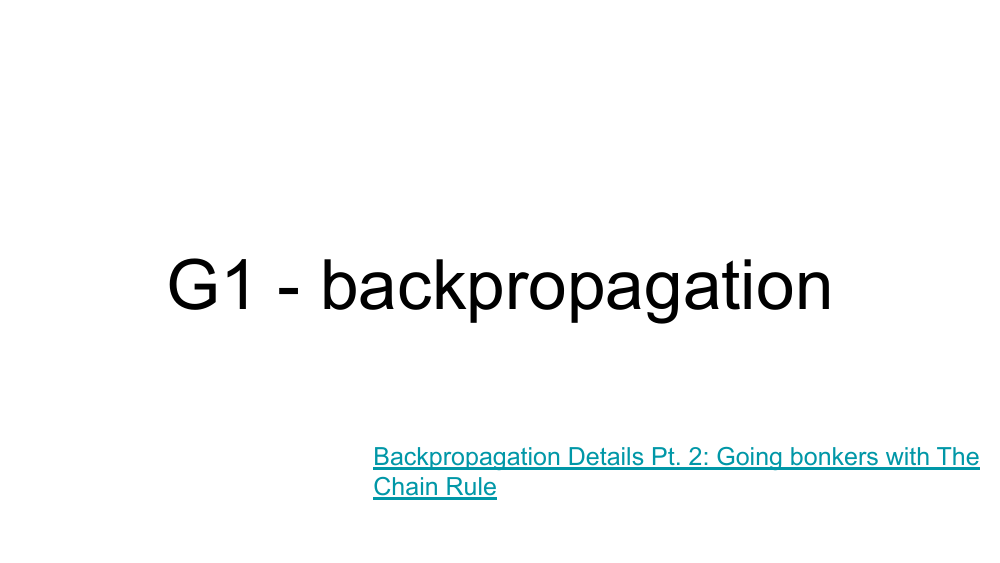

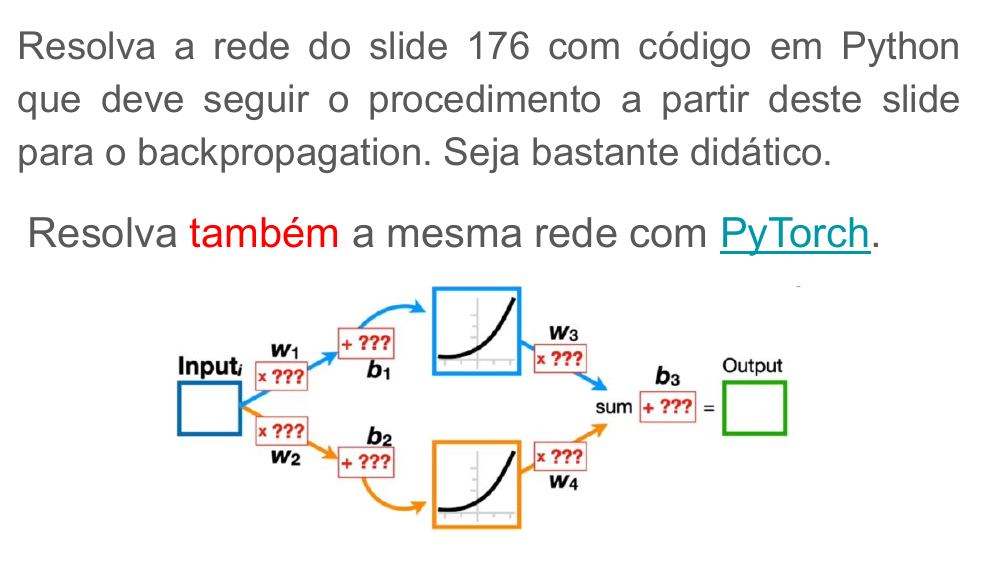

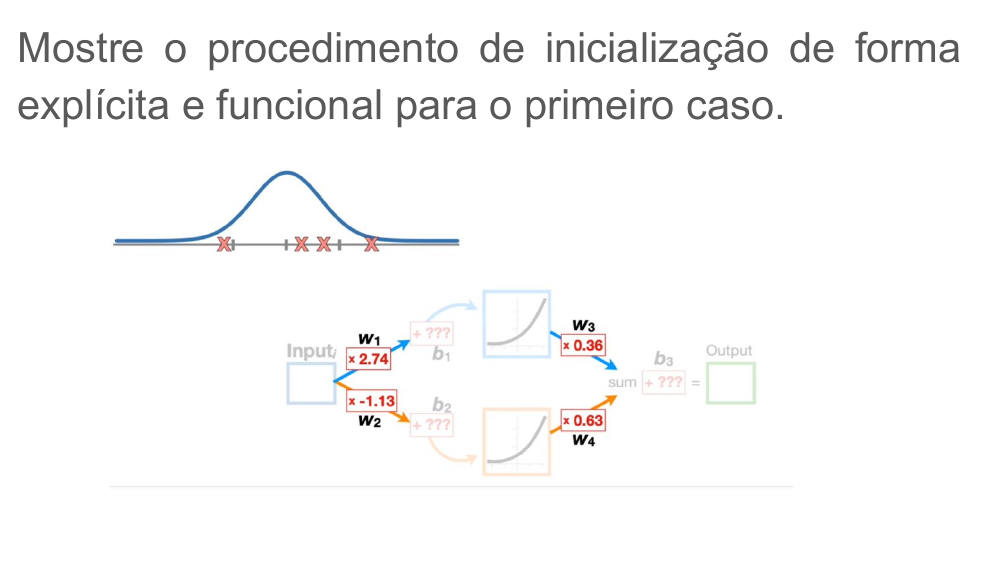

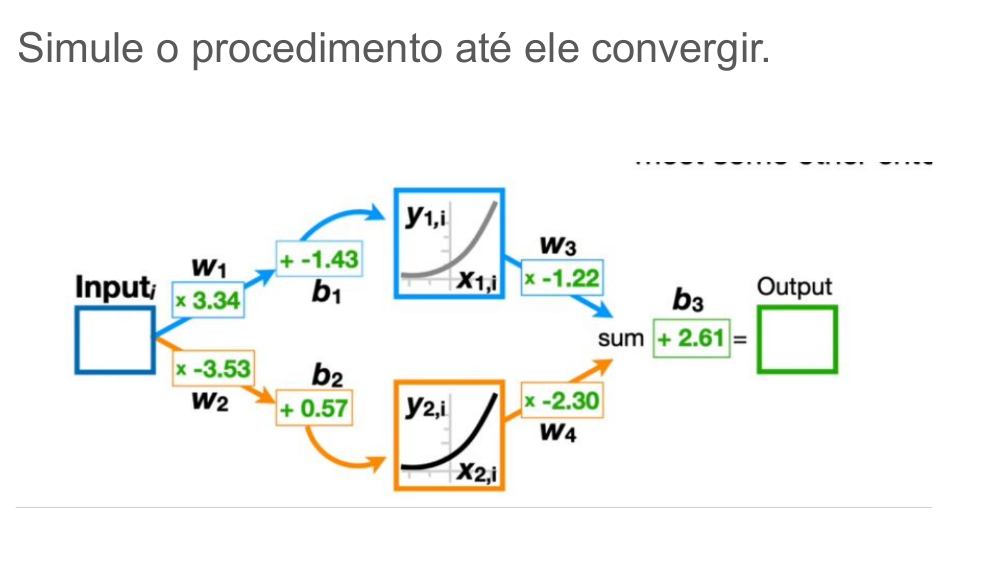

**Enunciado:** resolver a mesma rede do slide 176 (agora com **todos** os 7 parâmetros desconhecidos) implementando a retropropagação manualmente via regra da cadeia, e depois repetir o treinamento com PyTorch.

**Inicialização explícita (primeiro caso, slide 235):** w1=2.74, w2=-1.13, w3=0.36, w4=0.63, b1=b2=b3=0 (pesos amostrados de uma normal, vieses iniciados em 0).

Parâmetros finais (manual):
  w1 = 3.334
  b1 = -1.444
  w2 = -3.522
  b2 = 0.573
  w3 = -1.225
  w4 = -2.299
  b3 = 2.605
SSR final: 0.00000


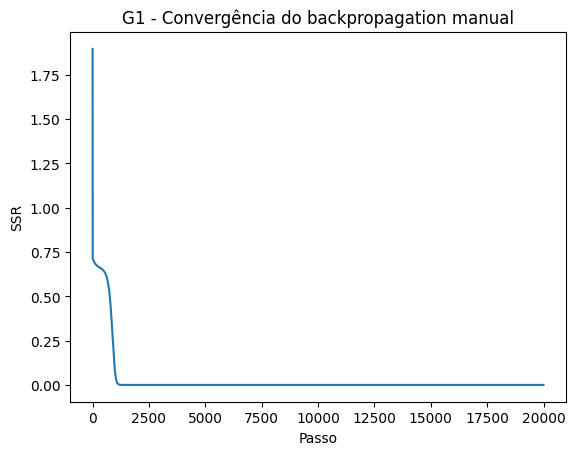

In [17]:
# --- Backpropagation manual (NumPy) ---
dosage_np = np.array([0.0, 0.5, 1.0])
efficacy_np = np.array([0.0, 1.0, 0.0])

def softplus(z):
    return np.log1p(np.exp(z))

def d_softplus(z):
    return 1 / (1 + np.exp(-z))  # sigmoid(z)

params = dict(w1=2.74, b1=0.0, w2=-1.13, b2=0.0, w3=0.36, w4=0.63, b3=0.0)
lr = 0.05
n_steps = 20000
loss_history = []

for step in range(n_steps):
    # forward
    z1 = params["w1"] * dosage_np + params["b1"]
    a1 = softplus(z1)
    z2 = params["w2"] * dosage_np + params["b2"]
    a2 = softplus(z2)
    pred = a1 * params["w3"] + a2 * params["w4"] + params["b3"]
    residual = efficacy_np - pred
    loss_history.append(np.sum(residual ** 2))

    # backward (regra da cadeia, SSR)
    d_pred = -2 * residual                      # dSSR/dpred
    d_b3 = np.sum(d_pred)
    d_w3 = np.sum(d_pred * a1)
    d_w4 = np.sum(d_pred * a2)
    d_a1 = d_pred * params["w3"]
    d_a2 = d_pred * params["w4"]
    d_z1 = d_a1 * d_softplus(z1)
    d_z2 = d_a2 * d_softplus(z2)
    d_w1 = np.sum(d_z1 * dosage_np)
    d_b1 = np.sum(d_z1)
    d_w2 = np.sum(d_z2 * dosage_np)
    d_b2 = np.sum(d_z2)

    for name, grad in zip(
        ["w1", "b1", "w2", "b2", "w3", "w4", "b3"],
        [d_w1, d_b1, d_w2, d_b2, d_w3, d_w4, d_b3]):
        params[name] -= lr * grad

print("Parâmetros finais (manual):")
for k, v in params.items():
    print(f"  {k} = {v:.3f}")
print(f"SSR final: {loss_history[-1]:.5f}")

plt.plot(loss_history)
plt.xlabel("Passo"); plt.ylabel("SSR"); plt.title("G1 - Convergência do backpropagation manual")
plt.show()

**Valores de referência (StatQuest):** w1≈3.34, b1≈-1.43, w2≈-3.53, b2≈0.57, w3≈-1.22, w4≈-2.30, b3≈2.61. Os parâmetros encontrados manualmente devem se aproximar destes valores (a rede pode convergir para uma solução equivalente, já que a ordem/sinal das duas unidades ocultas é intercambiável).

In [18]:
# --- Mesmo procedimento usando PyTorch (autograd) ---
torch.manual_seed(0)
dosage_t = torch.tensor([0.0, 0.5, 1.0])
efficacy_t = torch.tensor([0.0, 1.0, 0.0])

w1_t = torch.tensor(2.74, requires_grad=True)
b1_t = torch.tensor(0.0, requires_grad=True)
w2_t = torch.tensor(-1.13, requires_grad=True)
b2_t = torch.tensor(0.0, requires_grad=True)
w3_t = torch.tensor(0.36, requires_grad=True)
w4_t = torch.tensor(0.63, requires_grad=True)
b3_t = torch.tensor(0.0, requires_grad=True)

params_t = [w1_t, b1_t, w2_t, b2_t, w3_t, w4_t, b3_t]
opt_g1 = torch.optim.SGD(params_t, lr=0.05)
loss_fn_g1 = torch.nn.MSELoss(reduction='sum')

def forward_g1(x):
    a1 = F.softplus(x * w1_t + b1_t)
    a2 = F.softplus(x * w2_t + b2_t)
    return a1 * w3_t + a2 * w4_t + b3_t

loss_history_pt = []
for step in range(20000):
    opt_g1.zero_grad()
    pred = forward_g1(dosage_t)
    loss = loss_fn_g1(pred, efficacy_t)
    loss.backward()
    opt_g1.step()
    loss_history_pt.append(loss.item())

print("Parâmetros finais (PyTorch):")
for name, p in zip(["w1", "b1", "w2", "b2", "w3", "w4", "b3"], params_t):
    print(f"  {name} = {p.item():.3f}")
print(f"SSR final: {loss_history_pt[-1]:.5f}")

Parâmetros finais (PyTorch):
  w1 = 3.334
  b1 = -1.444
  w2 = -3.522
  b2 = 0.573
  w3 = -1.225
  w4 = -2.299
  b3 = 2.605
SSR final: 0.00000


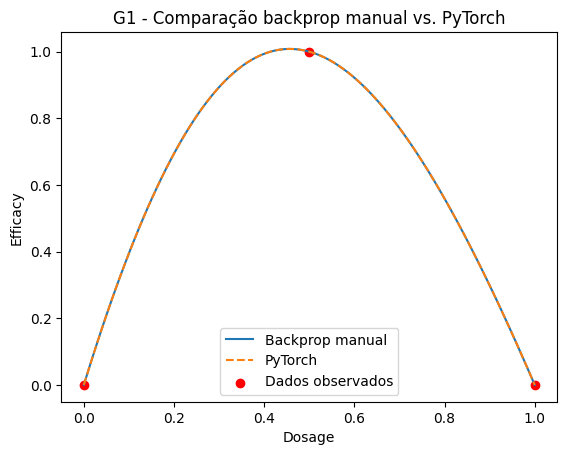

In [19]:
x_range = torch.linspace(0, 1, 100)
with torch.no_grad():
    y_manual = softplus(params["w1"]*x_range.numpy()+params["b1"])*params["w3"] + \
               softplus(params["w2"]*x_range.numpy()+params["b2"])*params["w4"] + params["b3"]
    y_pytorch = forward_g1(x_range).numpy()

plt.plot(x_range.numpy(), y_manual, label="Backprop manual")
plt.plot(x_range.numpy(), y_pytorch, '--', label="PyTorch")
plt.scatter(dosage_np, efficacy_np, color="red", label="Dados observados")
plt.xlabel("Dosage"); plt.ylabel("Efficacy"); plt.legend()
plt.title("G1 - Comparação backprop manual vs. PyTorch")
plt.show()

**Análise dos resultados e conclusão:** as duas implementações - retropropagação manual (derivadas obtidas via regra da cadeia) e PyTorch (autograd) - partem da mesma inicialização e convergem para curvas praticamente idênticas, o que valida a implementação manual da regra da cadeia. Isso demonstra na prática o que o autograd do PyTorch faz "por baixo dos panos": aplicar repetidamente a regra da cadeia, da saída para a entrada, para calcular o gradiente de cada parâmetro em relação à função de perda.